### Tutorial 1: Statistical Analysis and ML for Machine Failure Classification

Designed by: [Tirtharaj Dash](https://tirtharajdash.github.io) | March 2026

**Dataset:** AI4I 2020 Predictive Maintenance Dataset (UCI ML Repository)  
**Reference:** Matzka, S. (2020). *Explainable Artificial Intelligence for Predictive Maintenance Applications.*  
3rd Int. Conf. on AI for Industries (AI4I 2020). IEEE. DOI: 10.1109/AI4I49448.2020.00023  
**Source:** https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset

### Learning Objectives
- Understand basic descriptive statistics in the context of sensor data
- Visualise distributions and correlations of machine operating parameters
- Build and evaluate classification models (Logistic Regression, Random Forest) to predict machine failure
- Interpret feature importance for explainability

### Dataset Description
The dataset reflects a real predictive maintenance scenario. It contains 10,000 data points with the following features:
- `Air temperature [K]`, `Process temperature [K]`
- `Rotational speed [rpm]`, `Torque [Nm]`, `Tool wear [min]`
- `Machine failure` (binary label: 0/1)
- Failure sub-types: TWF (Tool Wear), HDF (Heat Dissipation), PWF (Power), OSF (Overstrain), RNF (Random)

### 1. Setup and Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

plt.rcParams['figure.dpi'] = 120
np.random.seed(42)

In [5]:
# Download the dataset directly from UCI

#somehow this link is broken or not working.
#url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
#df = pd.read_csv(url)

# Try the following; downloaded from: https://www.kaggle.com/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020?resource=download
df = pd.read_csv("data/ai4ai2020.zip")

print(df.shape)
df.head()

(10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [6]:
# Rename columns for convenience
df.columns = [
    'UDI', 'ProductID', 'Type',
    'AirTemp', 'ProcessTemp', 'RotSpeed',
    'Torque', 'ToolWear',
    'Failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'
]

# Encode product type: L=0, M=1, H=2
df['TypeCode'] = df['Type'].map({'L': 0, 'M': 1, 'H': 2})

print("Class distribution (Failure):")
print(df['Failure'].value_counts())
print(f"\nFailure rate: {df['Failure'].mean()*100:.2f}%")

Class distribution (Failure):
Failure
0    9661
1     339
Name: count, dtype: int64

Failure rate: 3.39%


### 2. Descriptive Statistics

Before any modelling, we summarise the sensor data to understand operating ranges, central tendency, and spread.

Key quantities:
- **Mean / Median**: central tendency
- **Standard deviation**: spread
- **Skewness**: asymmetry of the distribution
- **Kurtosis**: tail heaviness (excess kurtosis = 0 for Gaussian)

In [7]:
features = ['AirTemp', 'ProcessTemp', 'RotSpeed', 'Torque', 'ToolWear']

summary = df[features].agg(['mean', 'std', 'median', 'min', 'max'])
summary.loc['skewness'] = df[features].skew()
summary.loc['kurtosis'] = df[features].kurtosis()
summary.round(3)

,AirTemp,ProcessTemp,RotSpeed,Torque,ToolWear
mean,300.005,310.006,1538.776,39.987,107.951
std,2.000,1.484,179.284,9.969,63.654
median,300.100,310.100,1503.000,40.100,108.000
min,295.300,305.700,1168.000,3.800,0.000
max,304.500,313.800,2886.000,76.600,253.000
skewness,0.114,0.015,1.993,-0.010,0.027
kurtosis,-0.836,-0.500,7.393,-0.013,-1.167


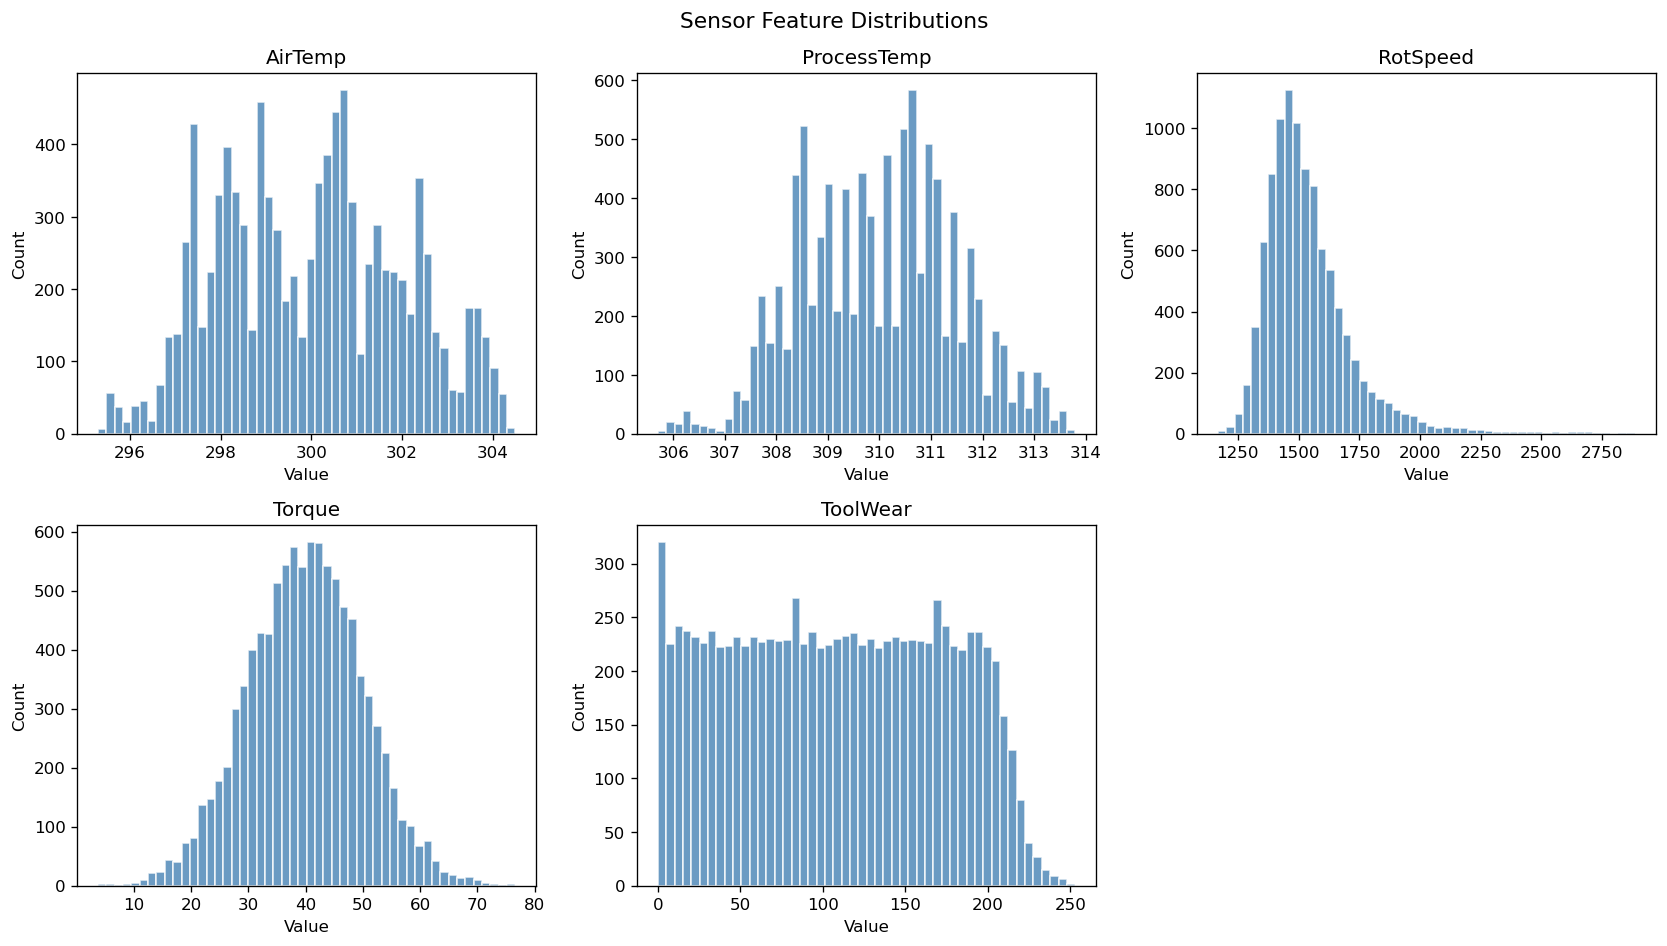

In [8]:
# Distribution plots for each sensor feature
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].hist(df[feat], bins=50, color='steelblue', alpha=0.8, edgecolor='white')
    axes[i].set_title(feat)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

axes[-1].axis('off')
plt.suptitle('Sensor Feature Distributions', fontsize=13)
plt.tight_layout()
plt.show()

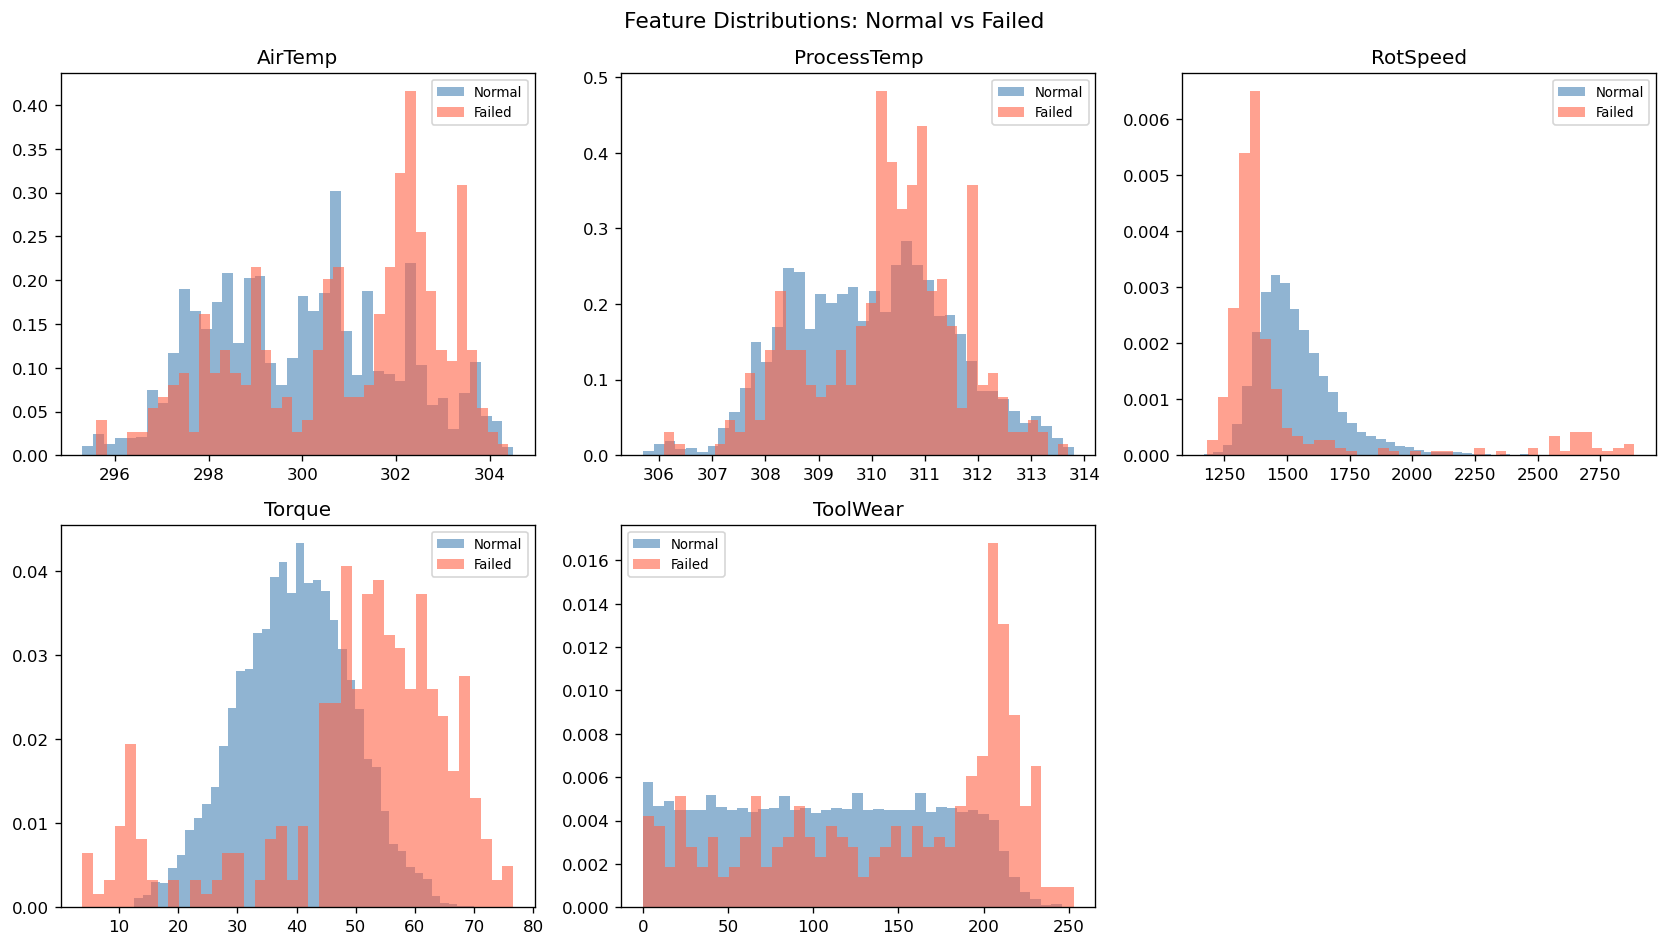

In [9]:
# Compare distributions between failed and non-failed machines
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    for label, color in [(0, 'steelblue'), (1, 'tomato')]:
        subset = df[df['Failure'] == label][feat]
        axes[i].hist(subset, bins=40, alpha=0.6, color=color,
                     label='Failed' if label == 1 else 'Normal', density=True)
    axes[i].set_title(feat)
    axes[i].legend(fontsize=8)

axes[-1].axis('off')
plt.suptitle('Feature Distributions: Normal vs Failed', fontsize=13)
plt.tight_layout()
plt.show()

### 3. Statistical Tests

We use the **two-sample t-test** (Welch's) to check whether sensor means differ significantly between failed and non-failed machines.

**Null hypothesis H0**: Mean is equal in both groups.  
Reject H0 if p-value < 0.05.

In [10]:
normal = df[df['Failure'] == 0]
failed = df[df['Failure'] == 1]

print(f"{'Feature':<20} {'t-stat':>10} {'p-value':>12} {'Significant?':>14}")
print('-' * 60)
for feat in features:
    t, p = stats.ttest_ind(normal[feat], failed[feat], equal_var=False)
    sig = 'Yes' if p < 0.05 else 'No'
    print(f"{feat:<20} {t:>10.3f} {p:>12.4e} {sig:>14}")

Feature                  t-stat      p-value   Significant?
------------------------------------------------------------
AirTemp                  -7.982   1.9508e-14            Yes
ProcessTemp              -3.898   1.1513e-04            Yes
RotSpeed                  2.087   3.7647e-02            Yes
Torque                  -11.781   3.6357e-27            Yes
ToolWear                 -9.264   1.9060e-18            Yes


### 4. Correlation Analysis

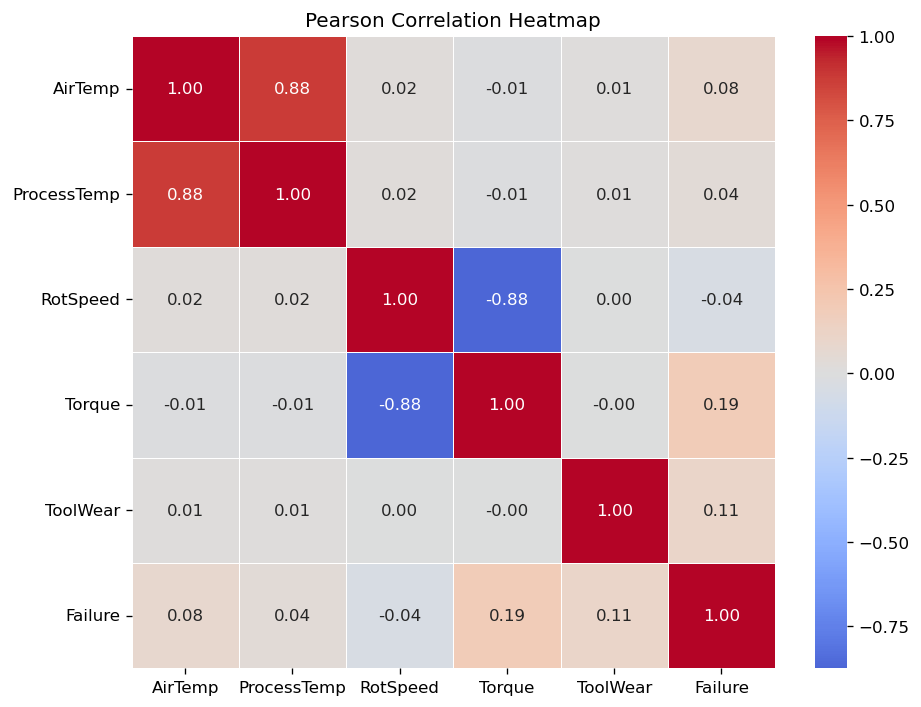

In [11]:
corr = df[features + ['Failure']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Pearson Correlation Heatmap')
plt.tight_layout()
plt.show()

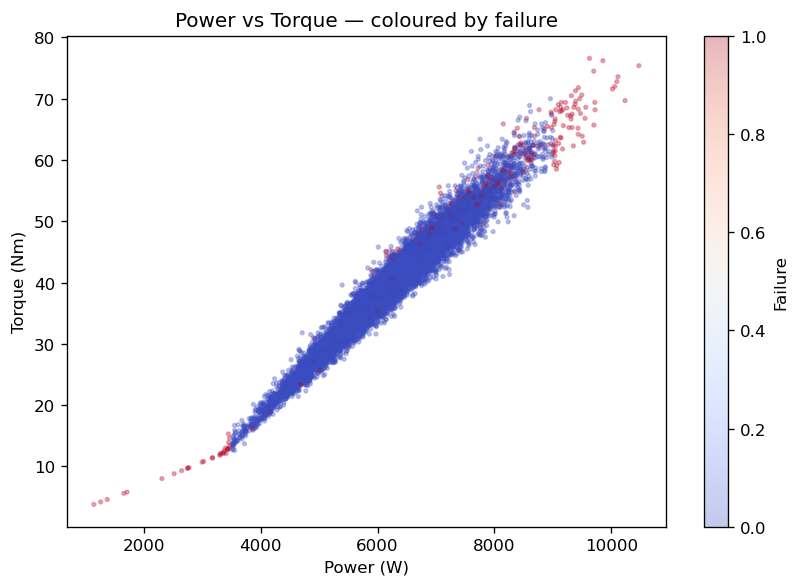

In [12]:
# Derived feature: Power = Torque * RotSpeed (physically meaningful)
df['Power'] = df['Torque'] * df['RotSpeed'] * (2 * np.pi / 60)  # in Watts

plt.figure(figsize=(7, 5))
plt.scatter(df['Power'], df['Torque'], c=df['Failure'],
            cmap='coolwarm', alpha=0.3, s=5)
plt.colorbar(label='Failure')
plt.xlabel('Power (W)')
plt.ylabel('Torque (Nm)')
plt.title('Power vs Torque — coloured by failure')
plt.tight_layout()
plt.show()

### 5. Machine Learning: Failure Classification

We train two classifiers:
1. **Logistic Regression** — linear, interpretable baseline
2. **Random Forest** — ensemble, captures non-linear interactions

Note: the dataset is class-imbalanced (~3.4% failure rate), so we use `class_weight='balanced'`.

In [13]:
X_cols = ['AirTemp', 'ProcessTemp', 'RotSpeed', 'Torque', 'ToolWear', 'TypeCode']
X = df[X_cols].values
y = df['Failure'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
print(f"Failure rate in train: {y_train.mean()*100:.2f}%")

Train size: 8000, Test size: 2000
Failure rate in train: 3.39%


In [14]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)

rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_train_s, y_train)

print("Models trained.")

Models trained.


In [15]:
def evaluate(model, X_te, y_te, model_name):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    print(f"\n=== {model_name} ===")
    print(classification_report(y_te, y_pred, target_names=['Normal', 'Failure']))
    print(f"ROC-AUC: {roc_auc_score(y_te, y_prob):.4f}")
    return y_prob

prob_lr = evaluate(lr, X_test_s, y_test, 'Logistic Regression')
prob_rf = evaluate(rf, X_test_s, y_test, 'Random Forest')


=== Logistic Regression ===
              precision    recall  f1-score   support

      Normal       0.99      0.82      0.90      1932
     Failure       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000

ROC-AUC: 0.9082

=== Random Forest ===
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99      1932
     Failure       0.93      0.57      0.71        68

    accuracy                           0.98      2000
   macro avg       0.96      0.79      0.85      2000
weighted avg       0.98      0.98      0.98      2000

ROC-AUC: 0.9683


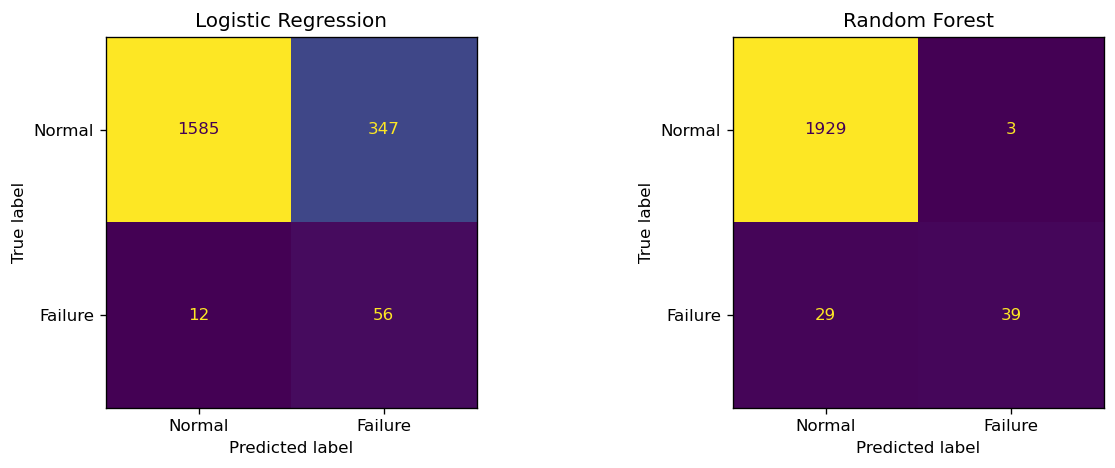

In [16]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, model, prob, name in [
    (axes[0], lr, prob_lr, 'Logistic Regression'),
    (axes[1], rf, prob_rf, 'Random Forest')
]:
    cm = confusion_matrix(y_test, model.predict(X_test_s))
    ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Failure']).plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

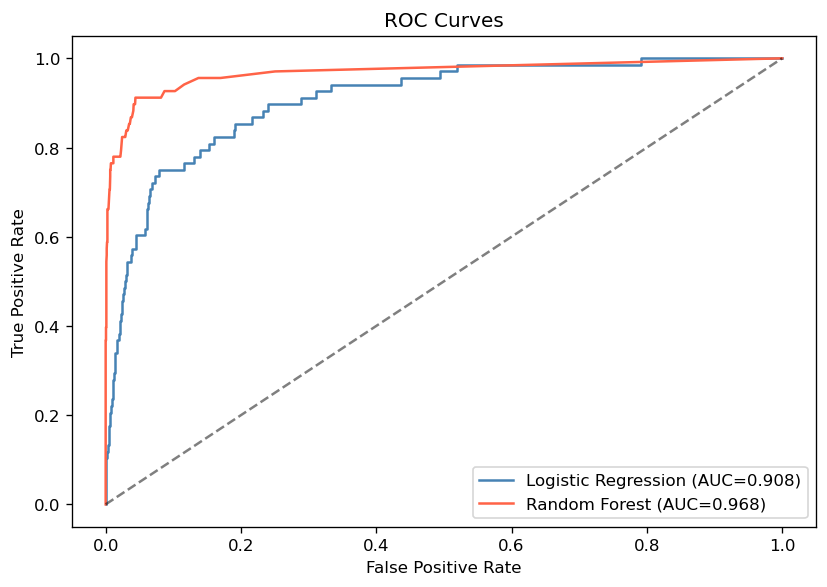

In [17]:
# ROC curves
fig, ax = plt.subplots(figsize=(7, 5))

for prob, name, color in [
    (prob_lr, 'Logistic Regression', 'steelblue'),
    (prob_rf, 'Random Forest', 'tomato')
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend()
plt.tight_layout()
plt.show()

### 6. Feature Importance (Random Forest)

Random Forest provides mean decrease in impurity (MDI) as a measure of feature importance.  
This tells us which sensor signals are most predictive of failure.

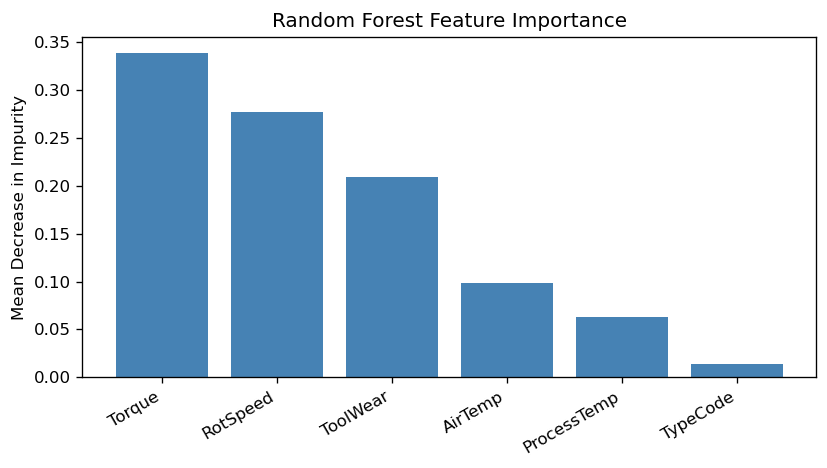

In [18]:
importances = rf.feature_importances_
idx = np.argsort(importances)[::-1]

plt.figure(figsize=(7, 4))
plt.bar(range(len(X_cols)), importances[idx], color='steelblue')
plt.xticks(range(len(X_cols)), [X_cols[i] for i in idx], rotation=30, ha='right')
plt.ylabel('Mean Decrease in Impurity')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

### 7. Failure Mode Breakdown

The dataset provides sub-labels for five failure modes. We analyse which modes co-occur and their relative frequency.

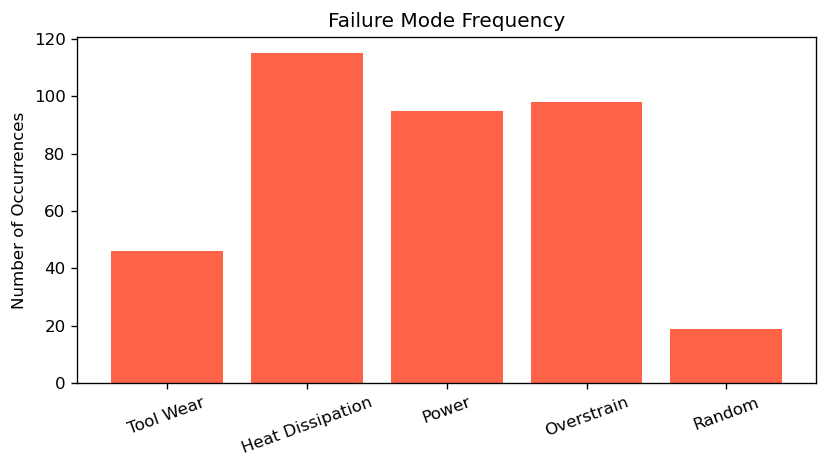

In [19]:
failure_modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
mode_labels = {
    'TWF': 'Tool Wear',
    'HDF': 'Heat Dissipation',
    'PWF': 'Power',
    'OSF': 'Overstrain',
    'RNF': 'Random'
}

counts = df[failure_modes].sum()

plt.figure(figsize=(7, 4))
plt.bar([mode_labels[m] for m in failure_modes], counts.values, color='tomato')
plt.ylabel('Number of Occurrences')
plt.title('Failure Mode Frequency')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

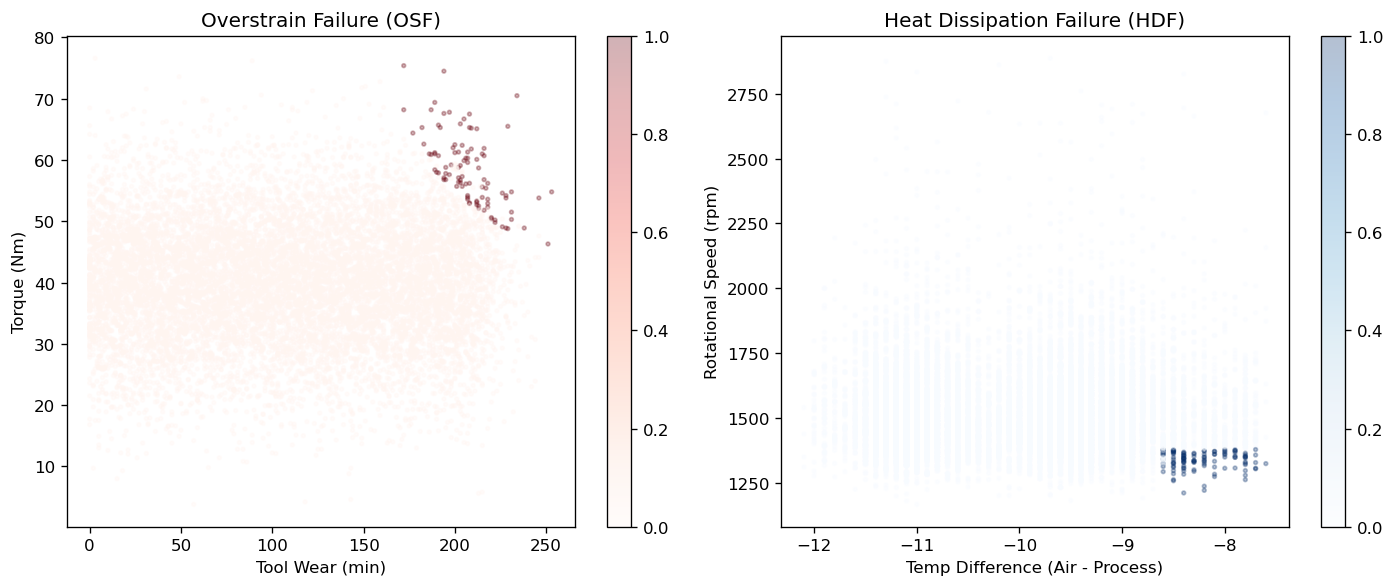

In [20]:
# Tool wear vs torque coloured by failure mode
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sc1 = axes[0].scatter(df['ToolWear'], df['Torque'], c=df['OSF'],
                       cmap='Reds', alpha=0.3, s=5)
axes[0].set_xlabel('Tool Wear (min)')
axes[0].set_ylabel('Torque (Nm)')
axes[0].set_title('Overstrain Failure (OSF)')
plt.colorbar(sc1, ax=axes[0])

sc2 = axes[1].scatter(df['AirTemp'] - df['ProcessTemp'], df['RotSpeed'],
                       c=df['HDF'], cmap='Blues', alpha=0.3, s=5)
axes[1].set_xlabel('Temp Difference (Air - Process)')
axes[1].set_ylabel('Rotational Speed (rpm)')
axes[1].set_title('Heat Dissipation Failure (HDF)')
plt.colorbar(sc2, ax=axes[1])

plt.tight_layout()
plt.show()

### Summary

- Statistical tests confirmed that **Torque** and **Tool Wear** differ most significantly between failed and normal machines.
- Random Forest significantly outperforms Logistic Regression on this imbalanced dataset, achieving higher recall for failure cases.
- Feature importance analysis identifies **Torque** and **Tool Wear** as the top predictors — consistent with domain knowledge (overstrain and wear-out are the dominant failure modes).
- The `HDF` mode is strongly linked to low temperature differences and extreme rotational speeds, which is physically interpretable.

### Further Reading
- Matzka, S. (2020). Explainable AI for Predictive Maintenance. *AI4I 2020*, IEEE. DOI: 10.1109/AI4I49448.2020.00023
- Hastie, T., Tibshirani, R., Friedman, J. (2009). *The Elements of Statistical Learning*. Springer. (Ch. 10 for Random Forests)
- Breiman, L. (2001). Random Forests. *Machine Learning*, 45, 5–32.